# Experiment 1: Quantile LSTM and Conformal Prediction on Synthetic Data

## Objective

This experiment establishes a baseline for uncertainty-aware time-series
forecasting using a Quantile LSTM and Conformal Prediction.

The experiment consists of:

1. Synthetic AR(1) time-series generation
2. Sliding-window sequence construction
3. LSTM-based quantile regression
4. Raw prediction interval construction
5. Split Conformal Prediction (SCP)
6. Conformalized Quantile Regression (CQR)
7. Coverage and interval-width evaluation

The nominal prediction interval is designed for 90% coverage.

## Mathematical Setup

The synthetic time series is generated according to

\[
y_t = \phi y_{t-1} + \epsilon_t,
\]

where

\[
\phi = 0.7,
\qquad
\epsilon_t \sim \mathcal{N}(0,1).
\]

For each time step, the previous five observations are used as input:

\[
X_t = (y_{t-5},y_{t-4},\ldots,y_{t-1}).
\]

The Quantile LSTM estimates the conditional lower and upper quantiles

\[
\hat Q_{0.1}(X_t), \qquad \hat Q_{0.9}(X_t).
\]

These define the raw prediction interval

\[
I_t^{raw}
=
[\hat Q_{0.1}(X_t),\hat Q_{0.9}(X_t)].
\]

The nominal coverage is

\[
1-\alpha = 0.90,
\qquad
\alpha=0.10.
\] 

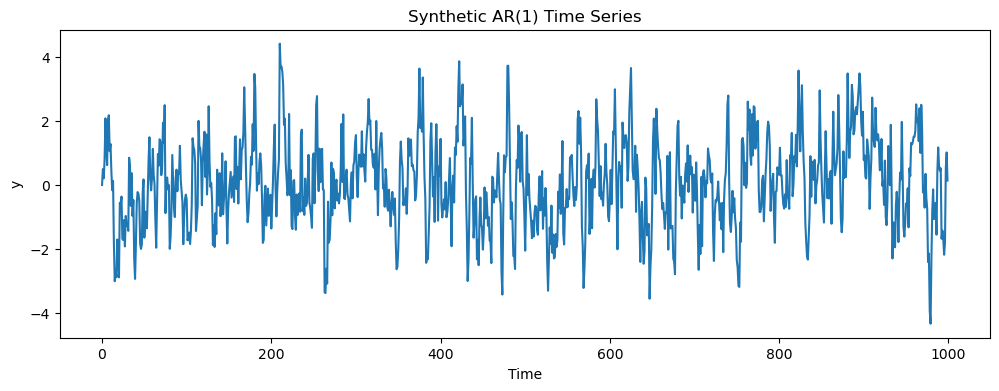

Raw data sizes:
Train: 700
Validation: 150
Test: 150

After creating sequences:
X_train: (695, 5)
y_train: (695,)
X_val: (145, 5)
y_val: (145,)
X_test: (145, 5)
y_test: (145,)

After adding feature dimension:
X_train: (695, 5, 1)
X_val: (145, 5, 1)
X_test: (145, 5, 1)

Tensor shapes:
X_train: torch.Size([695, 5, 1])
y_train: torch.Size([695])

One training batch:
X_batch: torch.Size([32, 5, 1])
y_batch: torch.Size([32])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 1. Generate Synthetic AR(1) Time Series
# ============================================================

np.random.seed(42)
torch.manual_seed(42)

n = 1000
phi = 0.7

y = np.zeros(n)

for t in range(1, n):
    noise = np.random.normal(0, 1)
    y[t] = phi * y[t - 1] + noise


# Visualize the time series

plt.figure(figsize=(12, 4))
plt.plot(y)
plt.xlabel("Time")
plt.ylabel("y")
plt.title("Synthetic AR(1) Time Series")
plt.show()


# ============================================================
# 2. Chronological Train / Validation / Test Split
# ============================================================

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train = y[:train_end]
val = y[train_end:val_end]
test = y[val_end:]

print("Raw data sizes:")
print("Train:", len(train))
print("Validation:", len(val))
print("Test:", len(test))


# ============================================================
# 3. Create Sliding-Window Sequences
# ============================================================

def create_sequences(data, seq_length):

    X = []
    y_target = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i + seq_length])
        y_target.append(data[i + seq_length])

    return np.array(X), np.array(y_target)


seq_length = 5

X_train, y_train = create_sequences(train, seq_length)
X_val, y_val = create_sequences(val, seq_length)
X_test, y_test = create_sequences(test, seq_length)


print("\nAfter creating sequences:")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# ============================================================
# 4. Add Feature Dimension
# ============================================================

# Before:
# X_train shape = (695, 5)
#
# After:
# X_train shape = (695, 5, 1)
#
# The final 1 means:
# 1 feature per timestep.

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]


print("\nAfter adding feature dimension:")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


# ============================================================
# 5. Convert NumPy Arrays Ã¢â€ â€™ PyTorch Tensors
# ============================================================

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


print("\nTensor shapes:")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)


# ============================================================
# 6. Create Dataset
# ============================================================

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)


# ============================================================
# 7. Create DataLoaders
# ============================================================

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# ============================================================
# 8. Inspect One Training Batch
# ============================================================

X_batch, y_batch = next(iter(train_loader))

print("\nOne training batch:")

print("X_batch:", X_batch.shape)
print("y_batch:", y_batch.shape)

In [40]:
import torch
import torch.nn as nn


class QuantileLSTM(nn.Module):

    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):

        output, (h_n, c_n) = self.lstm(x)

        # Last timestep
        last_hidden = output[:, -1, :]

        # Predict Q0.1 and Q0.9
        predictions = self.fc(last_hidden)

        return predictions


# Create model
model = QuantileLSTM(
    input_size=1,
    hidden_size=32
)

# Convert training data to tensor
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)


# Take first 10 samples
x_batch = X_train_tensor[:10]

# Forward pass
predictions = model(x_batch)


print("Input shape:", x_batch.shape)
print("Prediction shape:", predictions.shape)
print("Predictions:")
print(predictions)

Input shape: torch.Size([10, 5, 1])
Prediction shape: torch.Size([10, 2])
Predictions:
tensor([[ 0.0233, -0.0297],
        [ 0.0242, -0.0283],
        [ 0.0380, -0.0398],
        [ 0.0134, -0.0164],
        [-0.0009, -0.0013],
        [ 0.0173, -0.0168],
        [ 0.0194, -0.0200],
        [ 0.0390, -0.0386],
        [ 0.0653, -0.0660],
        [ 0.0725, -0.0774]], grad_fn=<AddmmBackward0>)


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_9948\1662703114.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(


In [ ]:
import torch.nn as nn


# ============================================================
# Define Pinball Loss for Quantile Regression
# ============================================================

class QuantileLoss(nn.Module):

    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = quantiles

    def forward(self, predictions, target):

        losses = []

        for i, q in enumerate(self.quantiles):

            # Actual - predicted quantile
            error = target - predictions[:, i]

            # Pinball loss
            loss = torch.maximum(
                q * error,
                (q - 1) * error
            )

            losses.append(loss)

        # [batch, 2]
        losses = torch.stack(losses, dim=1)

        # Average over batch and quantiles
        return losses.mean()


In [ ]:
# ============================================================
# Setup Model, Loss, and Optimizer
# ============================================================

# Rename tensors for clarity (or directly use the ones from data prep)
X_train_tensor = X_train
y_train_tensor = y_train
X_val_tensor = X_val
y_val_tensor = y_val

# Create model
model = QuantileLSTM(
    input_size=1,
    hidden_size=32
)

# Create loss function with quantiles [0.1, 0.9]
criterion = QuantileLoss(
    quantiles=[0.1, 0.9]
)

# Create optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model setup complete.")
print(f"Model: {model.__class__.__name__}")
print(f"Criterion: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__}")


In [46]:
num_epochs = 40

for epoch in range(num_epochs):

    model.train()

    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        predictions = model(X_batch)

        # Quantile loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = (
        total_train_loss / len(train_loader)
    )

    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    with torch.no_grad():

        val_predictions = model(
            X_val_tensor
        )

        val_loss = criterion(
            val_predictions,
            y_val_tensor
        )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss.item():.4f}"
    )

Epoch 1/40 | Train Loss: 0.4592 | Val Loss: 0.4149
Epoch 2/40 | Train Loss: 0.3697 | Val Loss: 0.3113
Epoch 3/40 | Train Loss: 0.2627 | Val Loss: 0.2280
Epoch 4/40 | Train Loss: 0.2252 | Val Loss: 0.2191
Epoch 5/40 | Train Loss: 0.2197 | Val Loss: 0.2123
Epoch 6/40 | Train Loss: 0.2141 | Val Loss: 0.2067
Epoch 7/40 | Train Loss: 0.2093 | Val Loss: 0.2017
Epoch 8/40 | Train Loss: 0.2047 | Val Loss: 0.1975
Epoch 9/40 | Train Loss: 0.2011 | Val Loss: 0.1934
Epoch 10/40 | Train Loss: 0.1973 | Val Loss: 0.1891
Epoch 11/40 | Train Loss: 0.1934 | Val Loss: 0.1837
Epoch 12/40 | Train Loss: 0.1896 | Val Loss: 0.1790
Epoch 13/40 | Train Loss: 0.1865 | Val Loss: 0.1755
Epoch 14/40 | Train Loss: 0.1838 | Val Loss: 0.1732
Epoch 15/40 | Train Loss: 0.1814 | Val Loss: 0.1715
Epoch 16/40 | Train Loss: 0.1793 | Val Loss: 0.1701
Epoch 17/40 | Train Loss: 0.1776 | Val Loss: 0.1692
Epoch 18/40 | Train Loss: 0.1761 | Val Loss: 0.1688
Epoch 19/40 | Train Loss: 0.1751 | Val Loss: 0.1687
Epoch 20/40 | Train L

In [47]:
model.eval()

with torch.no_grad():
    val_predictions = model(X_val_tensor)

print("First 10 quantile predictions:")
print(val_predictions[:10])

First 10 quantile predictions:
tensor([[-2.4891, -0.0368],
        [-3.0857, -0.5809],
        [-1.9464,  0.6411],
        [-2.7664, -0.1504],
        [-1.1146,  1.5278],
        [-2.6391, -0.0938],
        [-1.0234,  1.4560],
        [-0.8960,  1.5809],
        [-1.0542,  1.4253],
        [-1.5928,  0.9057]])


In [48]:
lower = val_predictions[:, 0]
upper = val_predictions[:, 1]

crossed = (lower > upper).sum().item()

print("Number of crossed intervals:", crossed)

Number of crossed intervals: 0


In [52]:
X_cal_tensor = X_val_tensor
y_cal_tensor = y_val_tensor

print("Calibration X shape:", X_cal_tensor.shape)
print("Calibration y shape:", y_cal_tensor.shape)

Calibration X shape: torch.Size([145, 5, 1])
Calibration y shape: torch.Size([145])


In [53]:
model.eval()

with torch.no_grad():
    cal_predictions = model(X_cal_tensor)

cal_lower = cal_predictions[:, 0]
cal_upper = cal_predictions[:, 1]

print("Calibration prediction shape:",
      cal_predictions.shape)

print("First 5 lower bounds:")
print(cal_lower[:5])

print("First 5 upper bounds:")
print(cal_upper[:5])

Calibration prediction shape: torch.Size([145, 2])
First 5 lower bounds:
tensor([-2.4891, -3.0857, -1.9464, -2.7664, -1.1146])
First 5 upper bounds:
tensor([-0.0368, -0.5809,  0.6411, -0.1504,  1.5278])


In [54]:
cal_scores = torch.maximum(
    cal_lower - y_cal_tensor,
    y_cal_tensor - cal_upper
)

cal_scores = torch.maximum(
    cal_scores,
    torch.zeros_like(cal_scores)
)

print("First 10 CQR scores:")
print(cal_scores[:10])

First 10 CQR scores:
tensor([0.1574, 0.0000, 0.2066, 0.3981, 0.7939, 0.4542, 0.0000, 0.0000, 0.0000,
        0.0000])


In [55]:
import math

n = len(cal_scores)
alpha = 0.10

k = math.ceil((n + 1) * (1 - alpha))

sorted_scores = torch.sort(cal_scores).values

q_cqr = sorted_scores[k - 1]

print("Number of calibration samples:", n)
print("k:", k)
print("CQR conformal q:", q_cqr.item())

Number of calibration samples: 145
k: 132
CQR conformal q: 0.31820768117904663


In [56]:
X_test_tensor = torch.as_tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.as_tensor(
    y_test,
    dtype=torch.float32
)

print("X_test shape:", X_test_tensor.shape)
print("y_test shape:", y_test_tensor.shape)

X_test shape: torch.Size([145, 5, 1])
y_test shape: torch.Size([145])


In [57]:
model.eval()

with torch.no_grad():
    test_quantiles = model(X_test_tensor)

test_lower_raw = test_quantiles[:, 0]
test_upper_raw = test_quantiles[:, 1]

print("Test quantile prediction shape:",
      test_quantiles.shape)

print("First 5 lower bounds:")
print(test_lower_raw[:5])

print("First 5 upper bounds:")
print(test_upper_raw[:5])

Test quantile prediction shape: torch.Size([145, 2])
First 5 lower bounds:
tensor([-0.9909, -0.1967, -0.6926, -1.6247, -1.2065])
First 5 upper bounds:
tensor([1.4650, 2.3271, 1.8791, 0.9521, 1.3717])


In [58]:
test_lower_cqr = test_lower_raw - q_cqr
test_upper_cqr = test_upper_raw + q_cqr

print("First 5 CQR intervals:")

for i in range(5):
    print(
        f"{i+1}: "
        f"[{test_lower_cqr[i].item():.4f}, "
        f"{test_upper_cqr[i].item():.4f}]"
    )

First 5 CQR intervals:
1: [-1.3091, 1.7832]
2: [-0.5149, 2.6453]
3: [-1.0108, 2.1974]
4: [-1.9429, 1.2703]
5: [-1.5247, 1.6899]


In [59]:
test_covered_cqr = (
    (y_test_tensor >= test_lower_cqr) &
    (y_test_tensor <= test_upper_cqr)
)

cqr_coverage = test_covered_cqr.float().mean().item()

print(f"CQR Coverage: {cqr_coverage:.4f}")
print(f"CQR Coverage (%): {cqr_coverage * 100:.2f}%")

CQR Coverage: 0.8828
CQR Coverage (%): 88.28%


In [60]:
cqr_width = test_upper_cqr - test_lower_cqr

print(
    "Average CQR interval width:",
    cqr_width.mean().item()
)

Average CQR interval width: 3.262651205062866


In [61]:
import numpy as np
import matplotlib.pyplot as plt

actuals = y_test_tensor.detach().cpu().numpy()
lower_cqr = test_lower_cqr.detach().cpu().numpy()
upper_cqr = test_upper_cqr.detach().cpu().numpy()

predictions = (
    test_lower_raw + test_upper_raw
) / 2

predictions = predictions.detach().cpu().numpy()

print("Actual:", actuals.shape)
print("Prediction:", predictions.shape)
print("Lower:", lower_cqr.shape)
print("Upper:", upper_cqr.shape)

Actual: (145,)
Prediction: (145,)
Lower: (145,)
Upper: (145,)


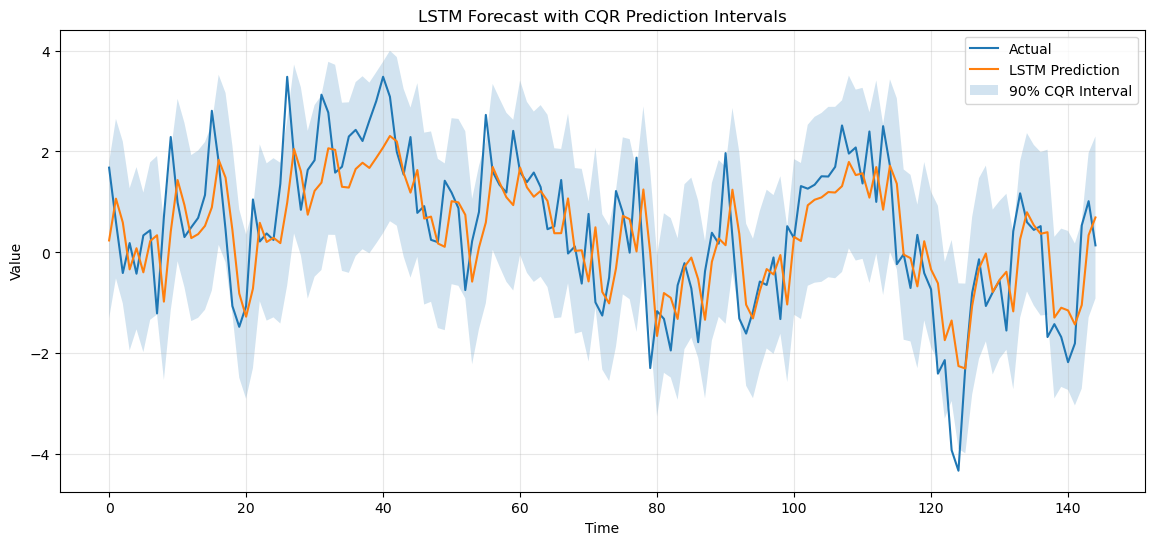

In [62]:
plt.figure(figsize=(14, 6))

x = np.arange(len(actuals))

plt.plot(
    x,
    actuals,
    label="Actual"
)

plt.plot(
    x,
    predictions,
    label="LSTM Prediction"
)

plt.fill_between(
    x,
    lower_cqr,
    upper_cqr,
    alpha=0.2,
    label="90% CQR Interval"
)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("LSTM Forecast with CQR Prediction Intervals")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# SCP: Split Conformal Prediction
# ============================================================

# Get validation predictions (midpoints of quantiles) for calibration
model.eval()
with torch.no_grad():
    val_quantiles = model(X_val_tensor)

val_lower = val_quantiles[:, 0]  # Q_0.1
val_upper = val_quantiles[:, 1]  # Q_0.9

# Point prediction: midpoint
val_predictions = (val_lower + val_upper) / 2

# Calibration residuals (absolute errors)
val_residuals = torch.abs(y_val_tensor - val_predictions)

# Convert to numpy for quantile computation
val_residuals_np = val_residuals.cpu().numpy()

# Compute SCP conformal quantile
n_val = len(val_residuals_np)
alpha = 0.10
k_scp = int(np.ceil((n_val + 1) * (1 - alpha)))
sorted_residuals_scp = np.sort(val_residuals_np)
q_scp = sorted_residuals_scp[k_scp - 1]

print(f"SCP Calibration: {n_val} samples")
print(f"k_scp: {k_scp}")
print(f"SCP conformal quantile q_scp: {q_scp:.4f}")


In [ ]:
# ==============================
# 1. Prepare all intervals
# ==============================

# SCP interval (using q_scp from calibration)
scp_lower = predictions - q_scp
scp_upper = predictions + q_scp

# Raw quantile interval
raw_lower = test_lower_raw.detach().cpu().numpy()
raw_upper = test_upper_raw.detach().cpu().numpy()

# CQR interval
cqr_lower = lower_cqr
cqr_upper = upper_cqr


# ==============================
# 2. Function for evaluation
# ==============================

def evaluate_interval(actual, lower, upper):

    covered = (
        (actual >= lower) &
        (actual <= upper)
    )

    coverage = covered.mean()

    width = upper - lower
    average_width = width.mean()

    return coverage, average_width


# ==============================
# 3. Evaluate all three
# ==============================

scp_coverage, scp_width = evaluate_interval(
    actuals,
    scp_lower,
    scp_upper
)

raw_coverage, raw_width = evaluate_interval(
    actuals,
    raw_lower,
    raw_upper
)

cqr_coverage, cqr_width = evaluate_interval(
    actuals,
    cqr_lower,
    cqr_upper
)


# ==============================
# 4. Print comparison
# ==============================

print("Method              Coverage       Avg Width")
print("-" * 50)

print(
    f"SCP                 {scp_coverage*100:.2f}%"
    f"          {scp_width:.4f}"
)

print(
    f"Raw Quantile        {raw_coverage*100:.2f}%"
    f"          {raw_width:.4f}"
)

print(
    f"CQR                 {cqr_coverage*100:.2f}%"
    f"          {cqr_width:.4f}"
)

Method              Coverage       Avg Width
--------------------------------------------------
SCP                 88.97%          3.3084
Raw Quantile        77.93%          2.6262
CQR                 88.28%          3.2627


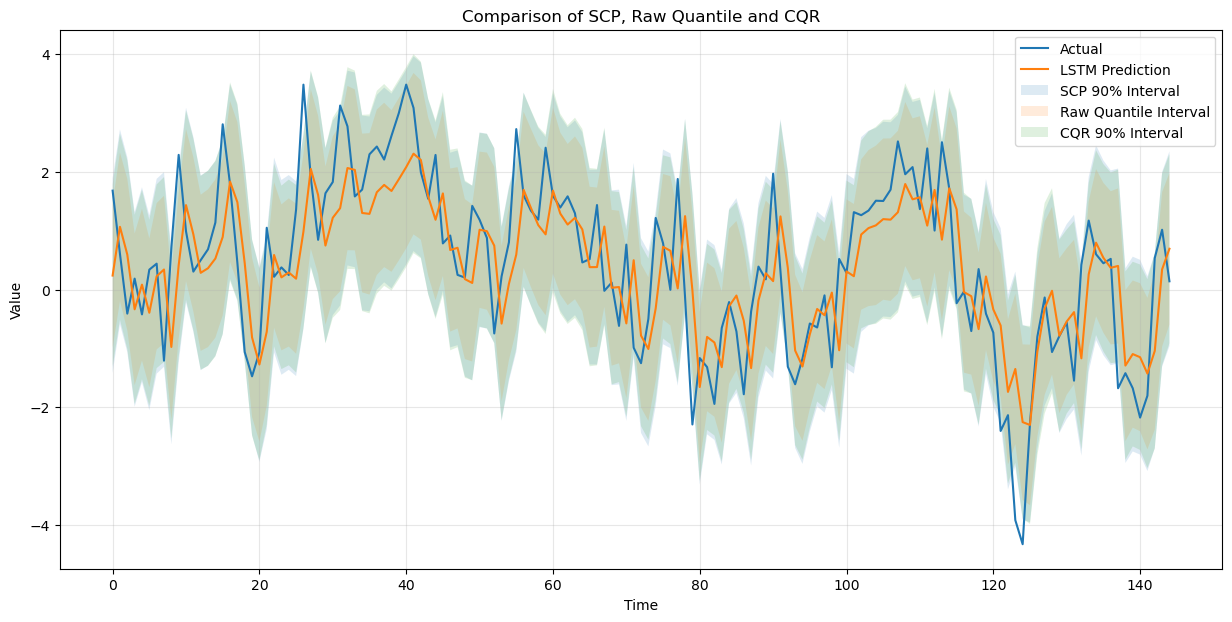

In [66]:
plt.figure(figsize=(15, 7))

x = np.arange(len(actuals))

# Actual
plt.plot(
    x,
    actuals,
    label="Actual"
)

# Point prediction
plt.plot(
    x,
    predictions,
    label="LSTM Prediction"
)

# SCP interval
plt.fill_between(
    x,
    scp_lower,
    scp_upper,
    alpha=0.15,
    label="SCP 90% Interval"
)

# Raw quantile interval
plt.fill_between(
    x,
    raw_lower,
    raw_upper,
    alpha=0.15,
    label="Raw Quantile Interval"
)

# CQR interval
plt.fill_between(
    x,
    cqr_lower,
    cqr_upper,
    alpha=0.15,
    label="CQR 90% Interval"
)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Comparison of SCP, Raw Quantile and CQR")

plt.legend()
plt.grid(alpha=0.3)

plt.show()